In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/amansinghnp/kaggleinputiam-handwriting-lines/lines.tgz
/kaggle/input/datasets/amansinghnp/kaggleinputiam-handwriting-lines/ascii.tgz


In [4]:
import cv2                  # adaptive thresholding, deskewing, morphological ops
import numpy as np          # array manipulation
from PIL import Image       # image I/O
import matplotlib.pyplot as plt  # visualising each preprocessing step
from skimage.filters import threshold_sauvola  # Sauvola binarization (better than Gaussian for handwriting)


In [5]:
import tarfile
import os

BASE = '/kaggle/input/datasets/amansinghnp/kaggleinputiam-handwriting-lines'

# Extract ascii (labels/transcriptions)
with tarfile.open(f'{BASE}/ascii.tgz', 'r:gz') as t:
    t.extractall('data/ascii')

# Extract lines (line-level image crops)
with tarfile.open(f'{BASE}/lines.tgz', 'r:gz') as t:
    t.extractall('data/lines')

print(os.listdir('data/ascii'))
print(os.listdir('data/lines'))


/tmp/ipykernel_55/749109887.py:8: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  t.extractall('data/ascii')
/tmp/ipykernel_55/749109887.py:12: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  t.extractall('data/lines')


['sentences.txt', 'words.txt', 'forms.txt', 'lines.txt']
['n02', 'g02', 'f02', 'a01', 'b05', 'l07', 'd04', 'g04', 'h02', 'p02', 'm01', 'b01', 'd03', 'm02', 'h05', 'p01', 'r02', 'm04', 'b06', 'b04', 'f01', 'k07', 'l03', 'd05', 'd01', 'f07', 'j04', 'c02', 'm03', 'c04', 'a04', 'h07', 'b02', 'h01', 'n04', 'a06', 'n01', 'l04', 'e07', 'g03', 'j07', 'a05', 'g07', 'r03', 'd06', 'g06', 'l01', 'h04', 'e06', 'e01', 'g05', 'r06', 'c03', 'j06', 'n03', 'k01', 'd07', 'a03', 'c01', 'p06', 'k02', 'f03', 'c06', 'e02', 'g01', 'j01', 'm06', 'n06', 'k03', 'p03', 'a02', 'h06', 'e04', 'b03', 'f04', 'k04']


In [6]:
import pandas as pd

records = []
with open('data/ascii/lines.txt', 'r') as f:
    for line in f:
        if line.startswith('#') or line.strip() == '':
            continue
        parts = line.strip().split(' ')
        records.append({
            'image_id': parts[0],
            'status':   parts[1],   # 'ok' or 'err'
            'text':     ' '.join(parts[8:])
        })

df = pd.DataFrame(records)

# Map image_id to file path
def id_to_path(image_id):
    p = image_id.split('-')
    return f"data/lines/{p[0]}/{p[0]}-{p[1]}/{image_id}.png"

df['path'] = df['image_id'].apply(id_to_path)
df['exists'] = df['path'].apply(os.path.exists)

print(df.shape)
print(df['status'].value_counts())
print(df['exists'].value_counts())
print(df.head())


(13353, 5)
status
ok     11344
err     2009
Name: count, dtype: int64
exists
True    13353
Name: count, dtype: int64
      image_id status                                   text  \
0  a01-000u-00     ok      A|MOVE|to|stop|Mr.|Gaitskell|from   
1  a01-000u-01     ok  nominating|any|more|Labour|life|Peers   
2  a01-000u-02     ok   is|to|be|made|at|a|meeting|of|Labour   
3  a01-000u-03    err   M Ps|tomorrow|.|Mr.|Michael|Foot|has   
4  a01-000u-04     ok   put|down|a|resolution|on|the|subject   

                                      path  exists  
0  data/lines/a01/a01-000u/a01-000u-00.png    True  
1  data/lines/a01/a01-000u/a01-000u-01.png    True  
2  data/lines/a01/a01-000u/a01-000u-02.png    True  
3  data/lines/a01/a01-000u/a01-000u-03.png    True  
4  data/lines/a01/a01-000u/a01-000u-04.png    True  


In [7]:
# Keep only clean samples + fix the pipe separator
df_clean = df[df['status'] == 'ok'].copy()
df_clean['text'] = df_clean['text'].str.replace('|', ' ', regex=False)

print(f"Clean samples: {len(df_clean)}")
print(df_clean['text'].head())


Clean samples: 11344
0            A MOVE to stop Mr. Gaitskell from
1        nominating any more Labour life Peers
2         is to be made at a meeting of Labour
4         put down a resolution on the subject
6    Griffiths , M P for Manchester Exchange .
Name: text, dtype: object


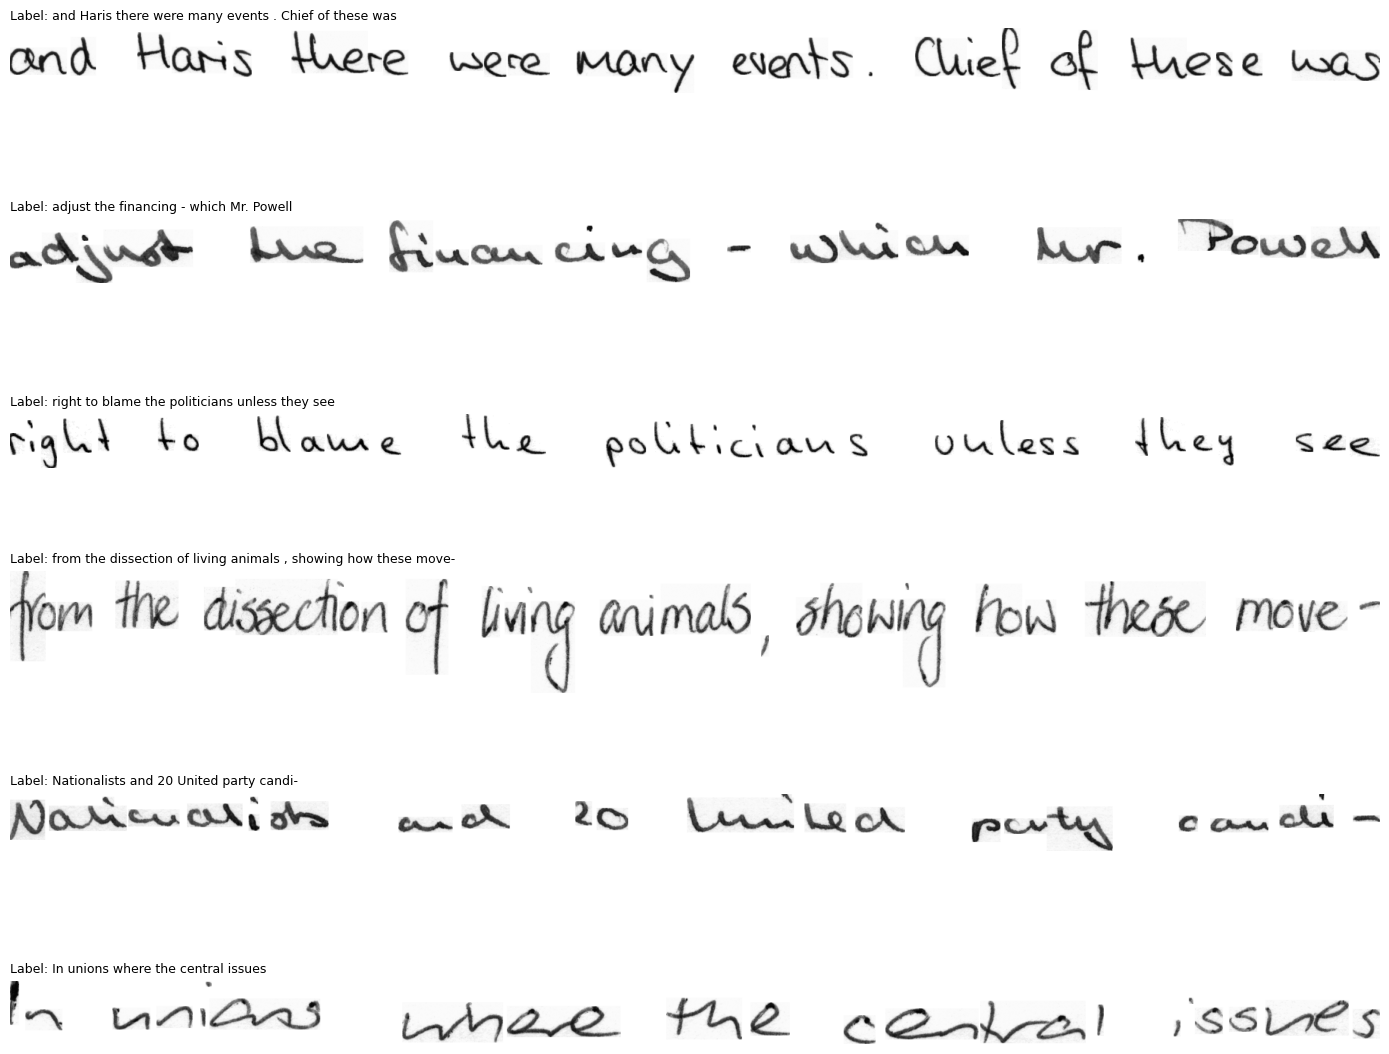

In [8]:
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(6, 1, figsize=(14, 12))
sample = df_clean.sample(6, random_state=42)

for ax, (_, row) in zip(axes, sample.iterrows()):
    img = Image.open(row['path'])
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Label: {row['text']}", fontsize=9, loc='left')
    ax.axis('off')

plt.tight_layout()
plt.savefig('samples.png')
plt.show()


Output shape: (64, 800)


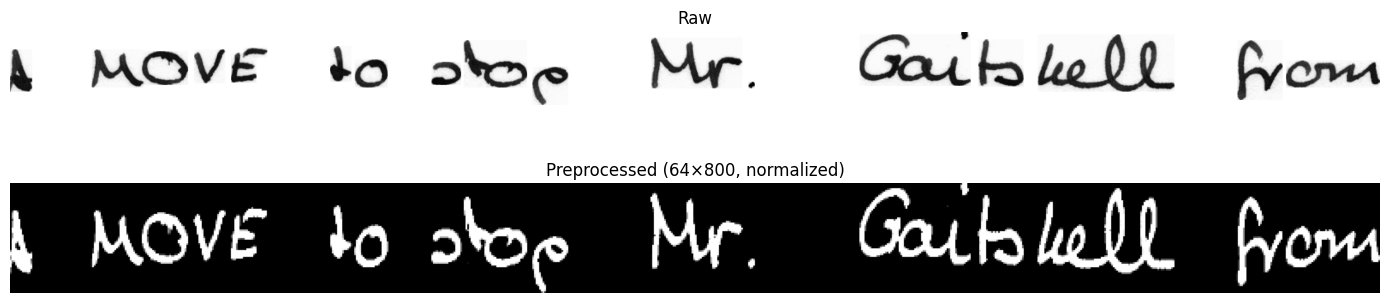

In [9]:
import cv2
import numpy as np
from PIL import Image

def preprocess(image_path, target_height=64, target_width=800):
    # Load as grayscale
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    # Sauvola-style: adaptive threshold to binarize
    img_bin = cv2.adaptiveThreshold(
        img, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        blockSize=31, C=10
    )

    # Invert if background is white (most IAM images are dark-on-white)
    if np.mean(img_bin) > 127:
        img_bin = cv2.bitwise_not(img_bin)

    # Crop tight around the text (remove excess whitespace)
    coords = cv2.findNonZero(img_bin)
    x, y, w, h = cv2.boundingRect(coords)
    img_cropped = img_bin[y:y+h, x:x+w]

    # Resize to fixed height, keep aspect ratio, then pad width
    scale = target_height / img_cropped.shape[0]
    new_w = min(int(img_cropped.shape[1] * scale), target_width)
    img_resized = cv2.resize(img_cropped, (new_w, target_height))

    # Pad to target_width with zeros (black background)
    pad_w = target_width - new_w
    img_padded = np.pad(img_resized, ((0, 0), (0, pad_w)), constant_values=0)

    # Normalize to [0, 1]
    img_norm = img_padded.astype(np.float32) / 255.0

    return img_norm


# Test on a single sample
sample_path = df_clean.iloc[0]['path']
processed = preprocess(sample_path)
print(f"Output shape: {processed.shape}")  # should be (64, 800)

# Visualise raw vs processed side by side
fig, axes = plt.subplots(2, 1, figsize=(14, 4))
axes[0].imshow(cv2.imread(sample_path, cv2.IMREAD_GRAYSCALE), cmap='gray')
axes[0].set_title('Raw')
axes[0].axis('off')
axes[1].imshow(processed, cmap='gray')
axes[1].set_title('Preprocessed (64×800, normalized)')
axes[1].axis('off')
plt.tight_layout()
plt.savefig('preprocessed_sample.png')
plt.show()


In [10]:
from tqdm.notebook import tqdm

X = []
y = []
failed = []

for _, row in tqdm(df_clean.iterrows(), total=len(df_clean)):
    try:
        img = preprocess(row['path'])
        X.append(img)
        y.append(row['text'])
    except Exception as e:
        failed.append(row['image_id'])

X = np.array(X, dtype=np.float32)  # shape: (11344, 64, 800)
print(f"X shape: {X.shape}")
print(f"Failed: {len(failed)}")

# Save to disk so you don't reprocess every time
np.save('X_processed.npy', X)

# Save labels
import json
with open('y_labels.json', 'w') as f:
    json.dump(y, f)

print("Saved X_processed.npy and y_labels.json")


  0%|          | 0/11344 [00:00<?, ?it/s]

X shape: (11344, 64, 800)
Failed: 0
Saved X_processed.npy and y_labels.json


In [11]:
# Build vocab from all labels
all_chars = sorted(set(''.join(y)))
vocab = ['<blank>'] + all_chars   # <blank> is the CTC blank token

char2idx = {c: i for i, c in enumerate(vocab)}
idx2char = {i: c for i, c in enumerate(vocab)}

print(f"Vocab size: {len(vocab)}")
print(f"Characters: {''.join(all_chars)}")

# Save vocab
with open('vocab.json', 'w') as f:
    json.dump(char2idx, f)


Vocab size: 80
Characters:  !"#&'()*+,-./0123456789:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz


In [12]:
from sklearn.model_selection import train_test_split

# Encode labels as list of int sequences
def encode_label(text, char2idx):
    return [char2idx[c] for c in text if c in char2idx]

y_encoded = [encode_label(text, char2idx) for text in y]

# Split indices
indices = list(range(len(X)))
idx_train, idx_temp = train_test_split(indices, test_size=0.2, random_state=42)
idx_val, idx_test   = train_test_split(idx_temp, test_size=0.5, random_state=42)

X_train, y_train = X[idx_train], [y_encoded[i] for i in idx_train]
X_val,   y_val   = X[idx_val],   [y_encoded[i] for i in idx_val]
X_test,  y_test  = X[idx_test],  [y_encoded[i] for i in idx_test]

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")


Train: 9075 | Val: 1134 | Test: 1135


In [13]:
import torch
import torch.nn as nn

class CRNN(nn.Module):
    def __init__(self, vocab_size, hidden_size=256):
        super().__init__()

        # CNN backbone — extracts spatial features
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32,  kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),  # 32x32x400
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),  # 64x16x200
            nn.Conv2d(64, 128,kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d((2,1)),  # 128x8x200
            nn.Conv2d(128,128,kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d((2,1)),  # 128x4x200
        )

        # BiLSTM — reads feature columns as a sequence
        self.rnn = nn.LSTM(
            input_size=128 * 4,    # CNN output height * channels
            hidden_size=hidden_size,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.3
        )

        # Output projection → vocab size
        self.fc = nn.Linear(hidden_size * 2, vocab_size)

    def forward(self, x):
        # x: (batch, 1, 64, 800)
        features = self.cnn(x)                          # (batch, 128, 4, 200)
        b, c, h, w = features.size()
        features = features.permute(0, 3, 1, 2)         # (batch, 200, 128, 4)
        features = features.reshape(b, w, c * h)        # (batch, 200, 512)
        output, _ = self.rnn(features)                  # (batch, 200, 512)
        output = self.fc(output)                        # (batch, 200, vocab_size)
        return output.permute(1, 0, 2)                  # (200, batch, vocab_size) ← CTC expects this

model = CRNN(vocab_size=len(vocab))
print(model)
print(f"\nTotal params: {sum(p.numel() for p in model.parameters()):,}")


CRNN(
  (cnn): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=(2, 1), stride=(2, 1), padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): MaxPool2d(kernel_size=(2, 1), stride=(2, 1), padding=0, dilation=1, ceil_mode=False)
  )
  (rnn): LSTM(512, 256, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (fc): Linear(in_features=512, out_features=80, bias=True)
)

Total params: 3,435,216


In [14]:
import torch
from torch.utils.data import Dataset, DataLoader

class IAMDataset(Dataset):
    def __init__(self, images, labels):
        self.images = images
        self.labels = labels

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = torch.tensor(self.images[idx]).unsqueeze(0)  # (1, 64, 800)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return img, label

def collate_fn(batch):
    images, labels = zip(*batch)
    images = torch.stack(images)                              # (batch, 1, 64, 800)
    label_lengths = torch.tensor([len(l) for l in labels])
    labels_concat = torch.cat(labels)                         # CTC needs flat concatenated labels
    return images, labels_concat, label_lengths

train_ds = IAMDataset(X_train, y_train)
val_ds   = IAMDataset(X_val,   y_val)
test_ds  = IAMDataset(X_test,  y_test)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  collate_fn=collate_fn)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, collate_fn=collate_fn)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, collate_fn=collate_fn)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")


Train batches: 284 | Val batches: 36


In [15]:
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
from PIL import Image
import torch

processor = TrOCRProcessor.from_pretrained('microsoft/trocr-base-handwritten')
model     = VisionEncoderDecoderModel.from_pretrained('microsoft/trocr-base-handwritten')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = model.to(device)
model.eval()
print(f"Loaded on: {device}")


preprocessor_config.json:   0%|          | 0.00/224 [00:00<?, ?B/s]

The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-handwritten
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.weight | MISSING | 
encoder.pooler.dense.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


generation_config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Loaded on: cuda


In [16]:
def predict(image_path):
    img = Image.open(image_path).convert('RGB')
    pixel_values = processor(images=img, return_tensors='pt').pixel_values.to(device)
    with torch.no_grad():
        generated_ids = model.generate(pixel_values)
    return processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

# Quick sanity check on 5 samples before running full eval
for _, row in df_clean.sample(5, random_state=7).iterrows():
    pred = predict(row['path'])
    print(f"Truth: {row['text']}")
    print(f"Pred:  {pred}\n")


Truth: if I had absolutely insisted on sailing at the
Pred:  if that absolutely insisted on sailing at the

Truth: to their aid .
Pred:  to their aid .

Truth: permission of American bases on our territory
Pred:  permission of American bases on our territory

Truth: ever since the symptoms had first
Pred:  ever since the symptoms had first

Truth: public of the change .
Pred:  peebles of the cleavage .



In [17]:
!pip install -q jiwer
from jiwer import cer, wer

truths, preds = [], []
for _, row in df_clean.iloc[idx_test].iterrows():
    truths.append(row['text'])
    preds.append(predict(row['path']))

print(f"CER: {cer(truths, preds):.4f}")
print(f"WER: {wer(truths, preds):.4f}")


CER: 0.0202
WER: 0.0537


/tmp/ipykernel_55/1176629479.py:14: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_55/1176629479.py:15: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('trocr_predictions.png')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


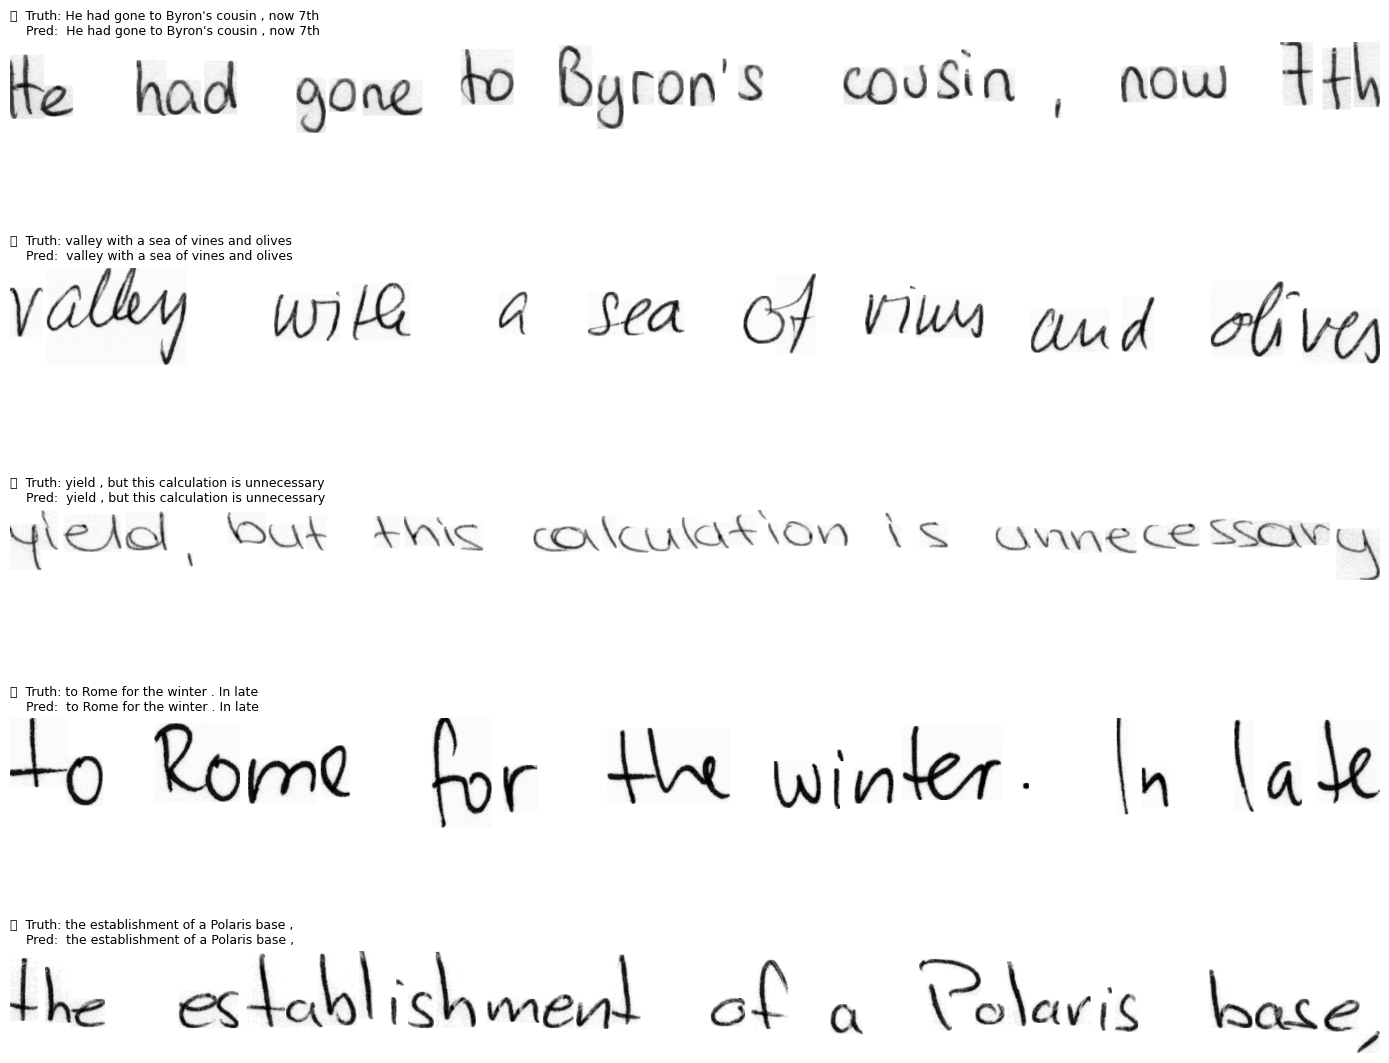

In [18]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(5, 1, figsize=(14, 12))
sample = df_clean.sample(5, random_state=99)

for ax, (_, row) in zip(axes, sample.iterrows()):
    img  = Image.open(row['path'])
    pred = predict(row['path'])
    match = "✅" if pred.strip().lower() == row['text'].strip().lower() else "❌"
    ax.imshow(img, cmap='gray')
    ax.set_title(f"{match}  Truth: {row['text']}\n    Pred:  {pred}", fontsize=9, loc='left')
    ax.axis('off')

plt.tight_layout()
plt.savefig('trocr_predictions.png')
plt.show()
